In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
# Plot configurations
%matplotlib inline
plt.style.use('default')
plt.style.use('ggplot')
plt.rc(
	'axes',
	titlesize=12,
	titlepad=10,
	titlecolor='black',
	titleweight='semibold',
	labelsize=8,
	labelpad=8,
	labelcolor='darkgray',
	grid=True
)
plt.rc(
	'grid',
	alpha=.75,
	linewidth=1
)

In [2]:
torch.manual_seed(42)

In [3]:
# Load the dataset from a verified working public URL
url = 'https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv'
df = pd.read_csv(url)
print(df.info())
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [6]:
from sklearn.preprocessing import LabelEncoder , StandardScaler
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], dtype=int)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [7]:
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.501400,0.250900,0.247700
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.500023,0.433553,0.431698
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,1.000000,0.000000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000,1.000000,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

CreditScore          0
Gender               0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_France     0
Geography_Germany    0
Geography_Spain      0
dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
X = df.drop('Exited', axis=1)
y = df['Exited']
# Split FIRST
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Scale AFTER splitting
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [11]:
import torch
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.float32)
  def __len__(self):
    return len(self.features)
  def __getitem__(self,idx):
    return self.features[idx],self.labels[idx]

In [13]:
train_dataset = CustomDataset(X_train, y_train.values)
val_dataset = CustomDataset(X_val, y_val.values)
test_dataset = CustomDataset(X_test, y_test.values)

In [14]:
df.shape

(10000, 13)

In [23]:
train_loader = DataLoader(
    train_dataset,
    batch_size=100,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=100,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=False
)

In [24]:
len(train_loader), len(test_loader)

(80, 10)

In [25]:
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128,64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(64,1)
    )

  def forward(self, x):
    return self.model(x)

In [35]:
learning_rate = 0.0001
epochs = 100

In [36]:
model = MyNN(X_train.shape[1])
model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate , weight_decay=1e-4)

In [37]:
train_losses = []
val_losses = []

best_val_loss = float('inf')
patience = 10
counter = 0

for epoch in range(epochs):

    # -------- TRAINING --------
    model.train()
    total_train_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        output = model(batch_features)

        loss = criterion(output.squeeze(), batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------- VALIDATION --------
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch_features, batch_labels in val_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            output = model(batch_features)

            loss = criterion(output.squeeze(), batch_labels)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # -------- EARLY STOPPING --------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0

        # Save best model
        best_model_state = model.state_dict()

    else:
        counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/100] Train Loss: 0.7069 Val Loss: 0.6485
Epoch [2/100] Train Loss: 0.6241 Val Loss: 0.5931
Epoch [3/100] Train Loss: 0.5726 Val Loss: 0.5506
Epoch [4/100] Train Loss: 0.5364 Val Loss: 0.5194
Epoch [5/100] Train Loss: 0.5020 Val Loss: 0.4886
Epoch [6/100] Train Loss: 0.4852 Val Loss: 0.4743
Epoch [7/100] Train Loss: 0.4655 Val Loss: 0.4580
Epoch [8/100] Train Loss: 0.4541 Val Loss: 0.4465
Epoch [9/100] Train Loss: 0.4431 Val Loss: 0.4336
Epoch [10/100] Train Loss: 0.4336 Val Loss: 0.4230
Epoch [11/100] Train Loss: 0.4274 Val Loss: 0.4145
Epoch [12/100] Train Loss: 0.4256 Val Loss: 0.4104
Epoch [13/100] Train Loss: 0.4200 Val Loss: 0.4056
Epoch [14/100] Train Loss: 0.4166 Val Loss: 0.4019
Epoch [15/100] Train Loss: 0.4165 Val Loss: 0.3968
Epoch [16/100] Train Loss: 0.4100 Val Loss: 0.3959
Epoch [17/100] Train Loss: 0.4056 Val Loss: 0.3907
Epoch [18/100] Train Loss: 0.4034 Val Loss: 0.3895
Epoch [19/100] Train Loss: 0.4008 Val Loss: 0.3853
Epoch [20/100] Train Loss: 0.3959 Val Lo

In [38]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

all_preds = []
all_targets = []

# Evaluate the model on the test data
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        outputs = model(batch_features)
        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
        preds = (torch.sigmoid(outputs).squeeze() >= 0.5).int().cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(batch_labels.numpy())

# Calculate metrics using sklearn functions
acc = accuracy_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds, zero_division=0)
recall = recall_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)
cm = confusion_matrix(all_targets, all_preds)
report = classification_report(all_targets, all_preds, zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

Accuracy:  0.8580
Precision: 0.7364
Recall:    0.4680
F1 Score:  0.5723

Confusion Matrix:
[[763  34]
 [108  95]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.91       797
         1.0       0.74      0.47      0.57       203

    accuracy                           0.86      1000
   macro avg       0.81      0.71      0.74      1000
weighted avg       0.85      0.86      0.85      1000



In [41]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()
print("Test accuracy")
print(correct/total)

Test accuracy
0.797


In [42]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()
print("Train accuracy")
print(correct/total)

Train accuracy
0.79625


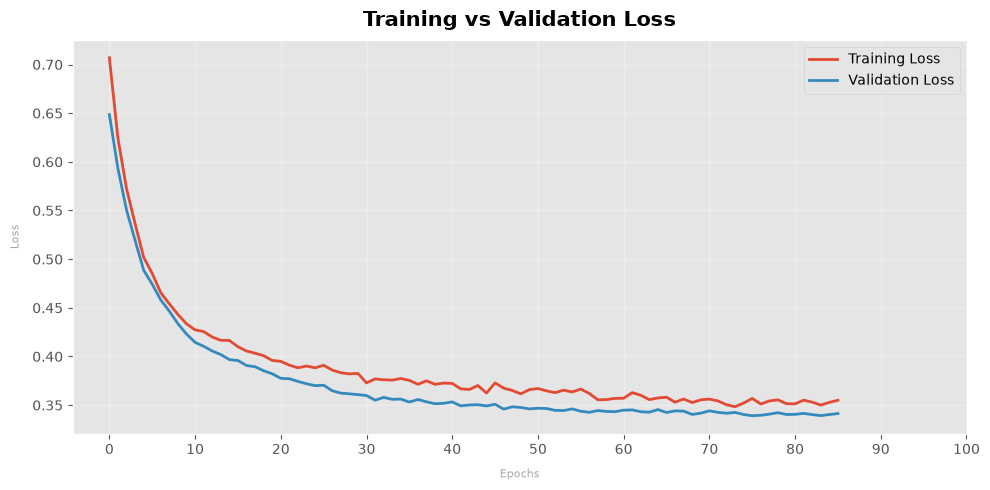

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss", fontsize=15, fontweight="bold")

plt.xticks(range(0, 101, 10))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

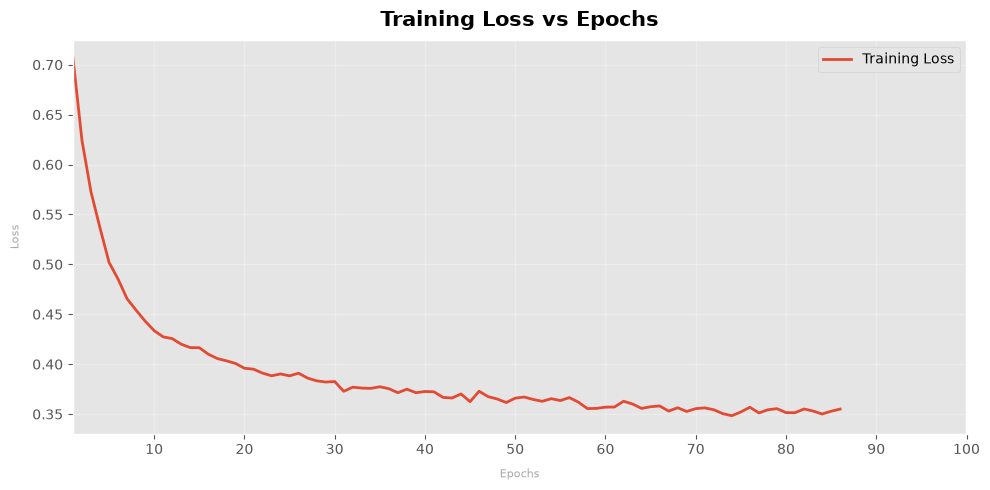

In [45]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_range,
    train_losses,
    linewidth=2,
    label="Training Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs", fontsize=15, fontweight="bold")

plt.xticks(range(0, 101, 10))
plt.xlim(1, 100)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()